In [2]:
from google.colab import files
uploaded = files.upload()

Saving web_traffic.csv to web_traffic.csv
Saving sales.csv to sales.csv
Saving sample_submission.csv to sample_submission.csv
Saving inventory.csv to inventory.csv


### 1. Import thư viện và cấu hình môi trường

Phần này import các thư viện cần thiết cho toàn bộ pipeline bao gồm xử lý dữ liệu, trực quan hóa, huấn luyện mô hình và đánh giá kết quả. Đồng thời thiết lập giá trị random seed nhằm đảm bảo tính tái lập (reproducibility) của kết quả, đúng theo yêu cầu của bài thi.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

### 2. Đọc dữ liệu đầu vào

Phần này đọc các file dữ liệu chính bao gồm dữ liệu doanh thu lịch sử (sales), file mẫu submission, dữ liệu lưu lượng truy cập (web traffic) và dữ liệu tồn kho (inventory).

Cột Date được chuyển sang định dạng datetime để phục vụ việc tạo các đặc trưng theo thời gian.

Lưu ý: file sample_submission chỉ được sử dụng để lấy khung ngày (Date). Các giá trị Revenue và COGS trong file này không được sử dụng vì đây là biến mục tiêu cần dự báo.

In [9]:
sales = pd.read_csv("sales.csv", parse_dates=["Date"])

# Chỉ lấy Date từ sample, bỏ Revenue/COGS để tránh nhầm với prediction có sẵn
sample = pd.read_csv("sample_submission.csv", usecols=["Date"], parse_dates=["Date"])

traffic = pd.read_csv("web_traffic.csv", parse_dates=["date"])
inventory = pd.read_csv("inventory.csv", parse_dates=["snapshot_date"])

print(sales.shape)
print(sample.shape)
print(traffic.shape)
print(inventory.shape)

sales.head()

(3833, 3)
(548, 1)
(3652, 7)
(60247, 17)


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


### 3. Kiểm tra cấu trúc dữ liệu ban đầu

Mục tiêu của bước này là hiểu sơ bộ dữ liệu trước khi xây dựng mô hình. Các thao tác bao gồm:
- Kiểm tra số dòng, số cột
- Kiểm tra kiểu dữ liệu từng cột
- Xem một vài dòng đầu

Việc này giúp phát hiện sớm các vấn đề như sai định dạng ngày, thiếu dữ liệu hoặc kiểu dữ liệu không phù hợp.





In [10]:
print(sales.info())
print(sales.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3833 non-null   datetime64[ns]
 1   Revenue  3833 non-null   float64       
 2   COGS     3833 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 90.0 KB
None
                      Date       Revenue          COGS
count                 3833  3.833000e+03  3.833000e+03
mean   2017-10-02 00:00:00  4.286584e+06  3.695134e+06
min    2012-07-04 00:00:00  2.798139e+05  2.365763e+05
25%    2015-02-17 00:00:00  2.471089e+06  2.150580e+06
50%    2017-10-02 00:00:00  3.647304e+06  3.161113e+06
75%    2020-05-17 00:00:00  5.350877e+06  4.637294e+06
max    2022-12-31 00:00:00  2.090527e+07  1.653586e+07
std                    NaN  2.624840e+06  2.219789e+06


### 4. Quan sát chuỗi thời gian Revenue

Biểu đồ này thể hiện doanh thu theo thời gian từ năm 2012 đến 2022. Đây là bước quan trọng để:
- Nhận diện xu hướng tăng trưởng dài hạn
- Quan sát tính mùa vụ (seasonality)
- Phát hiện các điểm bất thường (spike)

Những đặc điểm này sẽ định hướng cách xây dựng feature và mô hình dự báo.

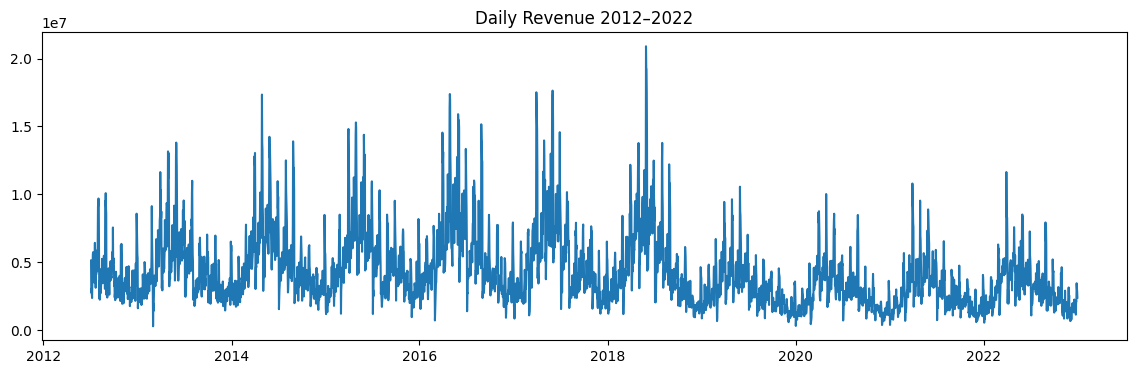

In [11]:

plt.figure(figsize=(14,4))
plt.plot(sales["Date"], sales["Revenue"])
plt.title("Daily Revenue 2012–2022")
plt.show()

### 5. Tạo đặc trưng theo thời gian (calendar features)

Từ cột Date, trích xuất các đặc trưng như:
- year, month, day
- day_of_week (thứ trong tuần)
- is_weekend (cuối tuần hay không)
- quarter, day_of_year

Các đặc trưng này giúp mô hình học được các quy luật lặp lại theo tuần, tháng và năm.

In [12]:
def add_calendar_features(df):
    df = df.copy()
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["day"] = df["Date"].dt.day
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df["quarter"] = df["Date"].dt.quarter
    df["day_of_year"] = df["Date"].dt.dayofyear
    return df

sales = add_calendar_features(sales)
sample = add_calendar_features(sample)

### 6. Tổng hợp dữ liệu web traffic theo ngày

Dữ liệu web traffic ban đầu có nhiều dòng cho mỗi ngày (theo từng nguồn traffic). Do đó cần tổng hợp lại theo ngày để phù hợp với dữ liệu doanh thu.

Các chỉ số như sessions, page views được cộng lại, trong khi bounce rate và thời gian phiên được lấy trung bình.

Các biến này đóng vai trò là tín hiệu nhu cầu (demand signal) vì lượng truy cập website thường liên quan trực tiếp đến doanh thu.

In [13]:
traffic_daily = (
    traffic
    .groupby("date")
    .agg({
        "sessions": "sum",
        "unique_visitors": "sum",
        "page_views": "sum",
        "bounce_rate": "mean",
        "avg_session_duration_sec": "mean"
    })
    .reset_index()
    .rename(columns={"date": "Date"})
)

sales = sales.merge(traffic_daily, on="Date", how="left")
sample = sample.merge(traffic_daily, on="Date", how="left")

### 7. Kết hợp dữ liệu web traffic vào tập train và test

Dữ liệu traffic được join vào bảng chính theo cột Date. Sử dụng left join để đảm bảo không mất ngày nào trong tập dữ liệu.

Đối với các ngày trong tương lai (test) chưa có traffic thực tế, giá trị được ước lượng bằng trung bình lịch sử theo tháng và ngày. Điều này giúp tránh sử dụng dữ liệu ngoài nhưng vẫn giữ được pattern mùa vụ.

In [14]:
traffic_cols = [
    "sessions",
    "unique_visitors",
    "page_views",
    "bounce_rate",
    "avg_session_duration_sec"
]

traffic_pattern = (
    sales
    .groupby(["month", "day"])[traffic_cols]
    .mean()
    .reset_index()
)

sample = sample.drop(columns=[c for c in traffic_cols if c in sample.columns])
sample = sample.merge(traffic_pattern, on=["month", "day"], how="left")

for col in traffic_cols:
    sales[col] = sales[col].fillna(sales[col].median())
    sample[col] = sample[col].fillna(sales[col].median())

### 8. Tổng hợp dữ liệu tồn kho theo tháng

Dữ liệu inventory được ghi nhận theo tháng và theo từng sản phẩm. Cần tổng hợp lại theo tháng để có thể gắn vào dữ liệu doanh thu theo ngày.

Các biến như tồn kho, số ngày hết hàng, fill rate phản ánh khả năng cung ứng sản phẩm, từ đó ảnh hưởng trực tiếp đến doanh thu.

In [15]:
inventory["year"] = inventory["snapshot_date"].dt.year
inventory["month"] = inventory["snapshot_date"].dt.month

inventory_monthly = (
    inventory
    .groupby(["year", "month"])
    .agg({
        "stock_on_hand": "sum",
        "units_received": "sum",
        "units_sold": "sum",
        "stockout_days": "sum",
        "days_of_supply": "mean",
        "fill_rate": "mean",
        "stockout_flag": "max",
        "overstock_flag": "max",
        "reorder_flag": "max",
        "sell_through_rate": "mean"
    })
    .reset_index()
)

sales = sales.merge(inventory_monthly, on=["year", "month"], how="left")
sample = sample.merge(inventory_monthly, on=["year", "month"], how="left")

### 9. Kết hợp dữ liệu tồn kho vào tập train và test

Dữ liệu inventory được join theo year và month. Điều này giúp mỗi ngày trong tháng có thông tin về tình trạng tồn kho.

Đối với tập test, khi không có dữ liệu tồn kho tương lai, các giá trị được điền bằng trung bình lịch sử theo tháng. Cách này giúp mô hình vẫn có thông tin supply mà không vi phạm quy định.

In [16]:
inventory_cols = [
    "stock_on_hand",
    "units_received",
    "units_sold",
    "stockout_days",
    "days_of_supply",
    "fill_rate",
    "stockout_flag",
    "overstock_flag",
    "reorder_flag",
    "sell_through_rate"
]

inventory_pattern = (
    sales
    .groupby("month")[inventory_cols]
    .mean()
    .reset_index()
)

sample = sample.drop(columns=[c for c in inventory_cols if c in sample.columns])
sample = sample.merge(inventory_pattern, on="month", how="left")

for col in inventory_cols:
    sales[col] = sales[col].fillna(sales[col].median())
    sample[col] = sample[col].fillna(sales[col].median())

### 10. Tạo đặc trưng lag từ Revenue

Lag feature là các giá trị doanh thu trong quá khứ, ví dụ:
- lag_1: doanh thu ngày hôm qua
- lag_7: doanh thu cùng ngày tuần trước
- lag_365: doanh thu cùng ngày năm trước

Đây là nhóm feature quan trọng nhất trong bài toán time series vì doanh thu hiện tại thường phụ thuộc mạnh vào lịch sử.

In [17]:
sales = sales.sort_values("Date").reset_index(drop=True)

for lag in [1, 7, 14, 30, 365]:
    sales[f"revenue_lag_{lag}"] = sales["Revenue"].shift(lag)

### 11. Tạo đặc trưng rolling (trung bình trượt)

Rolling mean và rolling std giúp mô hình hiểu được xu hướng ngắn hạn và độ biến động của doanh thu.

Ví dụ:
- rolling_mean_7: trung bình 7 ngày gần nhất
- rolling_std_30: độ biến động 30 ngày

Tất cả đều được shift trước khi tính để đảm bảo không sử dụng dữ liệu tương lai.

In [18]:
sales["revenue_roll_mean_7"] = sales["Revenue"].shift(1).rolling(7).mean()
sales["revenue_roll_mean_14"] = sales["Revenue"].shift(1).rolling(14).mean()
sales["revenue_roll_mean_30"] = sales["Revenue"].shift(1).rolling(30).mean()

sales["revenue_roll_std_7"] = sales["Revenue"].shift(1).rolling(7).std()
sales["revenue_roll_std_30"] = sales["Revenue"].shift(1).rolling(30).std()

### 12. Xử lý giá trị thiếu sau khi tạo lag

Việc tạo lag và rolling sẽ sinh ra các giá trị thiếu ở đầu chuỗi dữ liệu. Trong bước này, các dòng bị thiếu sẽ được loại bỏ.

Do dữ liệu lịch sử đủ dài (hơn 10 năm), việc loại bỏ này không ảnh hưởng đáng kể đến khả năng học của mô hình.

In [19]:
model_df = sales.dropna().copy()
print(model_df.shape)

(3468, 35)


### 13. Xác định tập đặc trưng và biến mục tiêu

Biến mục tiêu là Revenue.

Tập đặc trưng bao gồm:
- Calendar features (thời gian)
- Traffic features (nhu cầu)
- Inventory features (nguồn cung)
- Lag và rolling features (lịch sử doanh thu)

Việc kết hợp các nhóm feature này giúp mô hình chuyển từ baseline đơn giản sang mô hình dựa trên logic kinh doanh.

In [20]:
feature_cols = [
    "year", "month", "day", "day_of_week", "is_weekend", "quarter", "day_of_year",

    "sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec",

    "stock_on_hand", "units_received", "units_sold", "stockout_days",
    "days_of_supply", "fill_rate", "stockout_flag",
    "overstock_flag", "reorder_flag", "sell_through_rate",

    "revenue_lag_1", "revenue_lag_7", "revenue_lag_14", "revenue_lag_30", "revenue_lag_365",
    "revenue_roll_mean_7", "revenue_roll_mean_14", "revenue_roll_mean_30",
    "revenue_roll_std_7", "revenue_roll_std_30"
]

target = "Revenue"

### 14. Chia tập train và validation theo thời gian

Dữ liệu được chia theo thời gian:
- Train: đến hết 2021
- Validation: năm 2022

Cách chia này mô phỏng đúng bài toán thực tế, trong đó mô hình phải dự báo tương lai dựa trên quá khứ. Không sử dụng random split để tránh data leakage.

In [21]:
train_df = model_df[model_df["year"] <= 2021].copy()
val_df = model_df[model_df["year"] == 2022].copy()

X_train = train_df[feature_cols]
y_train = train_df[target]

X_val = val_df[feature_cols]
y_val = val_df[target]

print(X_train.shape, X_val.shape)

(3103, 32) (365, 32)


### 15. Huấn luyện mô hình LightGBM

LightGBM được sử dụng vì phù hợp với dữ liệu dạng bảng và có khả năng học quan hệ phi tuyến.

Early stopping được áp dụng dựa trên tập validation để tránh overfitting. Đây là bước kiểm tra nhanh xem pipeline đã hoạt động đúng hay chưa.

In [22]:
!pip install lightgbm -q

In [23]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    random_state=RANDOM_SEED
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000665 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4840
[LightGBM] [Info] Number of data points in the train set: 3103, number of used features: 29
[LightGBM] [Info] Start training from score 4365694.871304
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 595363	valid_0's l2: 7.03025e+11
[200]	valid_0's l1: 585876	valid_0's l2: 6.64198e+11
[300]	valid_0's l1: 577879	valid_0's l2: 6.42163e+11
[400]	valid_0's l1: 573365	valid_0's l2: 6.30658e+11
Early stopping, best iteration is:
[404]	valid_0's l1: 573070	valid_0's l2: 6.30238e+11


LGBMRegressor(learning_rate=0.03, n_estimators=1000, objective='regression',
              random_state=42)

### 16. Đánh giá mô hình trên tập validation

Sử dụng 3 chỉ số:
- MAE: độ lệch tuyệt đối trung bình
- RMSE: phạt nặng hơn các sai số lớn
- R²: tỷ lệ phương sai được giải thích bởi mô hình

Các chỉ số này giống với tiêu chí chấm điểm của đề bài, do đó cần theo dõi sát để đánh giá chất lượng mô hình

In [24]:
val_pred = model.predict(X_val)

mae = mean_absolute_error(y_val, val_pred)
mse = mean_squared_error(y_val, val_pred) # Calculate MSE
rmse = np.sqrt(mse) # Take the square root to get RMSE
r2 = r2_score(y_val, val_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 573070.3350659183
RMSE: 793874.9897605671
R2: 0.7750469062448329


### 17. So sánh giá trị thực và dự báo

Biểu đồ thể hiện hai đường:
- Doanh thu thực tế
- Doanh thu dự báo

Mục tiêu là kiểm tra trực quan xem mô hình có bắt được xu hướng và các đỉnh doanh thu hay không.

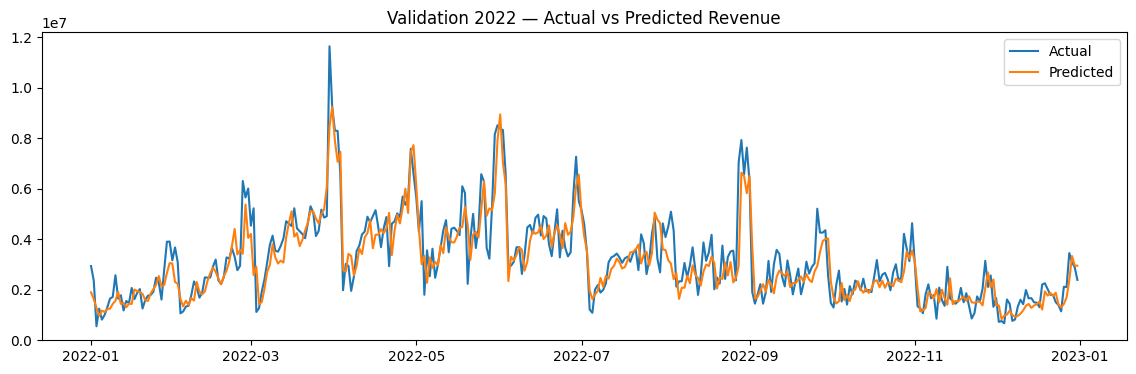

In [21]:
plt.figure(figsize=(14,4))
plt.plot(val_df["Date"], y_val.values, label="Actual")
plt.plot(val_df["Date"], val_pred, label="Predicted")
plt.title("Validation 2022 — Actual vs Predicted Revenue")
plt.legend()
plt.show()

### 18. Phân tích tầm quan trọng của đặc trưng

Bước này giúp hiểu mô hình đang dựa vào những yếu tố nào để đưa ra dự báo.

Thông thường các feature quan trọng sẽ bao gồm:
- lag_365 (cùng kỳ năm trước)
- rolling mean
- các biến calendar
- traffic và inventory

In [25]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
22,revenue_lag_1,1181
26,revenue_lag_365,1077
2,day,999
23,revenue_lag_7,751
25,revenue_lag_30,651
24,revenue_lag_14,624
6,day_of_year,587
10,bounce_rate,566
9,page_views,543
11,avg_session_duration_sec,537


### 19. Dự báo cho tập test bằng phương pháp recursive

Do tập test không có Revenue thực tế, việc tạo lag phải dựa trên các giá trị dự báo trước đó.

Quy trình:
- dự báo từng ngày
- thêm kết quả vào lịch sử
- dùng kết quả này để tạo feature cho ngày tiếp theo

Đây là cách mô phỏng đúng tình huống thực tế khi triển khai model.

In [26]:
full_history = sales[["Date", "Revenue"]].copy()
full_history = full_history.sort_values("Date").reset_index(drop=True)

test_pred_rows = []

test_base = sample.sort_values("Date").reset_index(drop=True).copy()

for i in range(len(test_base)):
    row = test_base.iloc[i].copy()
    current_date = row["Date"]

    temp_hist = full_history.copy()

    def get_lag(days):
        target_date = current_date - pd.Timedelta(days=days)
        value = temp_hist.loc[temp_hist["Date"] == target_date, "Revenue"]
        if len(value) > 0:
            return value.values[0]
        return np.nan

    row["revenue_lag_1"] = get_lag(1)
    row["revenue_lag_7"] = get_lag(7)
    row["revenue_lag_14"] = get_lag(14)
    row["revenue_lag_30"] = get_lag(30)
    row["revenue_lag_365"] = get_lag(365)

    hist_before = temp_hist[temp_hist["Date"] < current_date].sort_values("Date")

    row["revenue_roll_mean_7"] = hist_before["Revenue"].tail(7).mean()
    row["revenue_roll_mean_14"] = hist_before["Revenue"].tail(14).mean()
    row["revenue_roll_mean_30"] = hist_before["Revenue"].tail(30).mean()

    row["revenue_roll_std_7"] = hist_before["Revenue"].tail(7).std()
    row["revenue_roll_std_30"] = hist_before["Revenue"].tail(30).std()

    X_test_one = pd.DataFrame([row])[feature_cols]

    # fill NaN nếu có
    for col in feature_cols:
        if X_test_one[col].isnull().any():
            X_test_one[col] = X_test_one[col].fillna(model_df[col].median())

    pred = model.predict(X_test_one)[0]
    pred = max(pred, 0)

    test_pred_rows.append({
        "Date": current_date,
        "Revenue": pred
    })

    # thêm prediction vào history để dùng cho ngày sau
    full_history = pd.concat([
        full_history,
        pd.DataFrame({"Date": [current_date], "Revenue": [pred]})
    ], ignore_index=True)

test_revenue_pred = pd.DataFrame(test_pred_rows)
test_revenue_pred.head()

,Date,Revenue
0,2023-01-01,2.177572e+06
1,2023-01-02,1.837852e+06
2,2023-01-03,1.315804e+06
3,2023-01-04,1.124271e+06
4,2023-01-05,1.268445e+06


### 20. Ước lượng COGS từ Revenue

Trong Phase 1, COGS được tính dựa trên tỷ lệ lịch sử giữa COGS và Revenue.

Sau đó áp dụng ràng buộc:
COGS < Revenue

Điều này đảm bảo kết quả hợp lý về mặt kinh doanh.

In [27]:
cogs_ratio = (sales["COGS"] / sales["Revenue"]).median()
print("COGS ratio:", cogs_ratio)

test_revenue_pred["COGS"] = test_revenue_pred["Revenue"] * cogs_ratio

# đảm bảo logic COGS < Revenue
test_revenue_pred["COGS"] = np.minimum(
    test_revenue_pred["COGS"],
    test_revenue_pred["Revenue"] * 0.95
)

COGS ratio: 0.8216995431091048


### 21. Tạo file submission

File submission bao gồm 3 cột:
- Date
- Revenue
- COGS

Thứ tự dòng phải giữ nguyên theo sample_submission. Đây là yêu cầu bắt buộc của đề bài khi nộp lên hệ thống chấm điểm

In [28]:
submission = sample[["Date"]].merge(test_revenue_pred, on="Date", how="left")

submission["Revenue"] = submission["Revenue"].clip(lower=0)
submission["COGS"] = submission["COGS"].clip(lower=0)

submission["Date"] = submission["Date"].dt.strftime("%Y-%m-%d")

print(submission.head())
print(submission.shape)
print(submission.isnull().sum())

submission.to_csv("submission_v1.csv", index=False)

         Date       Revenue          COGS
0  2023-01-01  2.177572e+06  1.789310e+06
1  2023-01-02  1.837852e+06  1.510162e+06
2  2023-01-03  1.315804e+06  1.081196e+06
3  2023-01-04  1.124271e+06  9.238127e+05
4  2023-01-05  1.268445e+06  1.042281e+06
(548, 3)
Date       0
Revenue    0
COGS       0
dtype: int64


In [26]:
from google.colab import files
files.download("submission_v1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 23. Tổng kết Phase 1

Phase 1 xây dựng một pipeline dự báo hoàn chỉnh dựa trên:
- dữ liệu lịch sử
- đặc trưng thời gian
- tín hiệu từ traffic và inventory

So với baseline, mô hình này đã chuyển từ dự báo theo pattern sang dự báo dựa trên yếu tố kinh doanh.

Kết quả đầu ra:
- mô hình LightGBM
- các chỉ số đánh giá
- biểu đồ validation
- file submission_v1.csv

Đây là nền tảng để tiếp tục cải tiến ở các phase tiếp theo.